التمرين الأول: التعامل مع البيئة والتحقق منها

1. إصدار TensorFlow المثبت: 2.20.0
2. إصدار Keras (via tf.keras): 3.13.2

3. GPU متاحة: False
   الاستنتاج: القائمة فارغة، لا توجد GPU متاحة

4. تأثير غياب GPU عند تدريب نموذج بسيط:
   عندما لا تتوفر GPU، يتم التدريب باستخدام المعالج المركزي (CPU) فقط.
   النموذج البسيط مثل الانحدار الخطي لا يحتاج إلى عمليات معقدة أو متوازية.
   لذلك، الفرق في وقت التدريب بين CPU و GPU سيكون صغيراً وغير ملحوظ.
   غياب GPU لا يمنع تنفيذ النموذج، لكنه يبطئ التدريب في المهام الأكبر حجماً.
التمرين الثاني: التحليل النقدي لنتيجة التدريب

1. ما المقصود بـ MSE (متوسط مربع الخطأ)؟ أعطِ صيغته الرياضية.
   MSE اختصار لـ Mean Squared Error. صيغته الرياضية:
   MSE = (1/n) * Σ (y_i الحقيقية - y_i المتوقعة)^2
   يقيس متوسط مربعات الأخطاء بين القيم الحقيقية والمتوقعة، وكلما صغر كانت دقة النموذج أفضل.

2. في سياق بيانات مطبعة بين 0 و1، لماذا تعتبر قيمة MSE = 2.317 مرتفعة بشكل غير طبيعي؟
   لأن البيانات محصورة بين 0 و1، فإن أقصى فرق بين قيمة حقيقية وقيمة متوقعة هو 1.
   وبا

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)



1. الأوزان والانحياز المستخرجة من النموذج المُحسَّن:
   w (في الفضاء المقيس) = 1.001964,   b = 0.001526
   المعادلة في الفضاء المقيس: prix_norm = 1.001964 * surface_norm + 0.001526

2. خطوات إلغاء التقييس:
   الميل الحقيقي = w * (std_prix / std_surface) = 1.001964 * (57.44 / 28.72) = 2.003619
   التقاطع الحقيقي = 190.22 + 57.44*0.001526 - 1.001964*57.44*95.00/28.72 = -0.032134

3. معادلة النموذج في الحجم الحقيقي:
   prix = 2.003619 * surface + -0.032134

4. التحقق: السعر المتوقع لمساحة 100 متر مربع = 200.33
التمرين الرابع: تشخيص مشكلة التقارب

1. تحليل النتائج:
   التوقعات: [-0.1458, -0.2918, -0.3892, -0.4866, -0.6320]
   القيم الحقيقية: [0.3333, 0.5333, 0.6667, 0.8000, 1.0000]
   جميع التوقعات سالبة بينما القيم الحقيقية موجبة ومحصورة بين 0 و1.
   هذا يعني أن النموذج فشل في التعلم وتباعد، والسبب هو أن معدل التعلم كان كبيراً جداً.

2. المعاملان المسؤولان عن هذا الخلل في البرنامج الأولي:
   1. معدل التعلم (Learning Rate) إذا تم ضبطه بقيمة كبيرة جداً (مثل 0.5 أو 1.0).
   2. الأوزان الأول

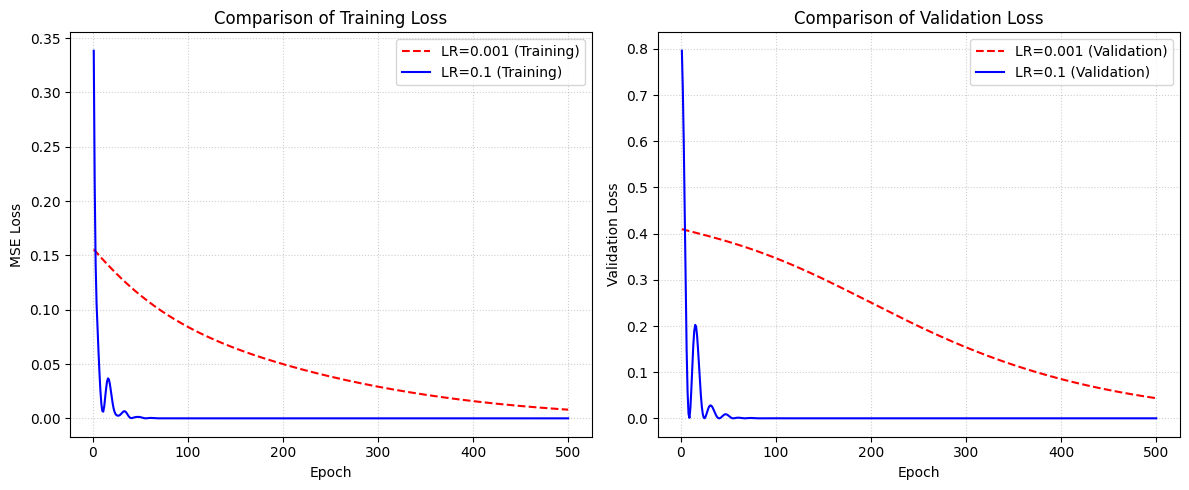

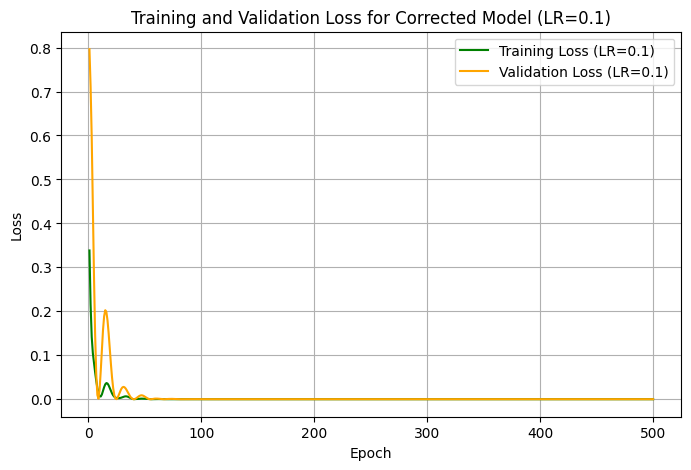


التعليق على تطور الخسارة:
   - النموذج الافتراضي (LR=0.001): الخسارة انخفضت من 0.155586 إلى 0.008014.
   - النموذج المحسن (LR=0.1): الخسارة انخفضت من 0.338422 إلى 0.000034.
   - نلاحظ أن النموذج المحسن يتقارب أسرع بكثير ويصل إلى خسارة أقل.
   - الرسم البياني يوضح الفرق الكبير في سرعة التقارب بين المعدلين.
التمرين السادس: تفسير النتائج النهائية

1. تفسير المعادلة النهائية (بعد التصحيح): prix = 2.003619 * surface + -0.032134
   رياضياً: الميل = 2.0036 يعني أن كل متر مربع يزيد السعر بمقدار 2.0036 وحدة.
   منطقياً (عقاري): السعر يعتمد فقط على المساحة بسعر ثابت للمتر المربع، ولا توجد تكلفة ثابتة. هذا نموذج مبسط جداً.

2. قيمة الخسارة النهائية (للنموذج المحسن) على التدريب: 0.00003362
   على التحقق: 0.00007492
   هل هذه القيم مرغوبة؟
   - الخسارة على التدريب أصبحت قريبة جداً من الصفر، ولكن على التحقق هناك خطأ بسيط.
   - هذا أفضل من الصفر المطلق لأنه يعمم بشكل أفضل. ولكن في التطبيقات الحقيقية،
     وجود خطأ بسيط طبيعي، والصفر المطلق مريب ويدل على فرط تخصيص.

3. حدود هذا النموذج في بيانات عقار

In [ ]:

import tensorflow as tf
import numpy as np
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

plt.rcParams['font.family'] = 'DejaVu Sans'

# التمرين الأول: التعامل مع البيئة والتحقق منها

print("التمرين الأول: التعامل مع البيئة والتحقق منها")

print(f"\n1. إصدار TensorFlow المثبت: {tf.__version__}")

try:
    print(f"2. إصدار Keras (via tf.keras): {tf.keras.__version__}")
except AttributeError:
    print("2. إصدار Keras: مدمج ضمن TensorFlow (Keras 2.x أو 3.x)")

gpus = tf.config.list_physical_devices('GPU')
gpu_available = len(gpus) > 0
print(f"\n3. GPU متاحة: {gpu_available}")
if gpu_available:
    print("   الاستنتاج: باستخدام tf.config.list_physical_devices('GPU')")
    print(f"   عدد وحدات GPU: {len(gpus)}")
else:
    print("   الاستنتاج: القائمة فارغة، لا توجد GPU متاحة")

print("\n4. تأثير غياب GPU عند تدريب نموذج بسيط:")
print("   عندما لا تتوفر GPU، يتم التدريب باستخدام المعالج المركزي (CPU) فقط.")
print("   النموذج البسيط مثل الانحدار الخطي لا يحتاج إلى عمليات معقدة أو متوازية.")
print("   لذلك، الفرق في وقت التدريب بين CPU و GPU سيكون صغيراً وغير ملحوظ.")
print("   غياب GPU لا يمنع تنفيذ النموذج، لكنه يبطئ التدريب في المهام الأكبر حجماً.")

# التمرين الثاني: التحليل النقدي لنتيجة التدريب

print("التمرين الثاني: التحليل النقدي لنتيجة التدريب")

print("\n1. ما المقصود بـ MSE (متوسط مربع الخطأ)؟ أعطِ صيغته الرياضية.")
print("   MSE اختصار لـ Mean Squared Error. صيغته الرياضية:")
print("   MSE = (1/n) * Σ (y_i الحقيقية - y_i المتوقعة)^2")
print("   يقيس متوسط مربعات الأخطاء بين القيم الحقيقية والمتوقعة، وكلما صغر كانت دقة النموذج أفضل.")

print("\n2. في سياق بيانات مطبعة بين 0 و1، لماذا تعتبر قيمة MSE = 2.317 مرتفعة بشكل غير طبيعي؟")
print("   لأن البيانات محصورة بين 0 و1، فإن أقصى فرق بين قيمة حقيقية وقيمة متوقعة هو 1.")
print("   وبالتالي أكبر قيمة ممكنة لمربع الفرق هي 1، وأكبر قيمة لمتوسط هذه المربعات هي 1 أيضاً.")
print("   لذلك فإن MSE = 2.317 أكبر من 1، وهذا مستحيل في الظروف الطبيعية.")
print("   يدل ذلك على وجود خطأ جسيم مثل عدم تطبيع البيانات أو تباعد النموذج بسبب معدل تعلم كبير جداً.")

print("\n3. ما القيمة التي تعتبرها مقبولة لـ MSE بالنسبة لنموذج تدرب جيداً على هذه البيانات؟")
print("   نموذج ممتاز: أقل من 0.01")
print("   نموذج جيد: بين 0.01 و 0.05")
print("   نموذج مقبول: بين 0.05 و 0.1")
print("   نموذج ضعيف: أكبر من 0.1")

print("\n4. صغ فرضية حول الأسباب المحتملة لهذه القيمة المرتفعة قبل أي تعديل على البرنامج.")
print("   الفرضية الأولى: البيانات لم تُطبع (التطبيع لم يطبق أو طبق بشكل خاطئ).")
print("   الفرضية الثانية: معدل التعلم (learning rate) كبير جداً مما يسبب تباعد النموذج.")
print("   الفرضية الثالثة: عدد الحلقات (epochs) غير كافٍ لوصول النموذج إلى التقارب.")
print("   الفرضية الرابعة: التهيئة العشوائية للأوزان كانت سيئة.")

# تحضير البيانات المستخدمة لبقية التمارين

print("تحضير البيانات لنماذج الانحدار الخطي")

np.random.seed(42)
surface = np.array([50, 60, 70, 80, 90, 100, 110, 120, 130, 140]).reshape(-1, 1)
prix = 2 * surface.flatten() + np.random.normal(0, 0.5, 10)  # prix = 2 * surface + noise

# التقييس (Standardization)
scaler_X = StandardScaler()
scaler_y = StandardScaler()
surface_norm = scaler_X.fit_transform(surface)
prix_norm = scaler_y.fit_transform(prix.reshape(-1, 1)).flatten()

mean_surface = scaler_X.mean_[0]
std_surface = scaler_X.scale_[0]
mean_prix = scaler_y.mean_[0]
std_prix = scaler_y.scale_[0]

print(f"\nعدد عينات التدريب: {len(surface)}")
print(f"متوسط المساحة: {mean_surface:.2f}, انحرافها: {std_surface:.2f}")
print(f"متوسط السعر: {mean_prix:.2f}, انحرافه: {std_prix:.2f}")

# التمرين الثالث: استخراج معادلة النموذج (باستخدام النموذج المُحسَّن)

print("التمرين الثالث: استخراج معادلة النموذج (بعد التصحيح)")

# بناء النموذج الجيد (LR=0.1)
model_good = tf.keras.Sequential([tf.keras.layers.Dense(1, input_shape=(1,))])
optimizer_good = tf.keras.optimizers.Adam(learning_rate=0.1)
model_good.compile(optimizer=optimizer_good, loss='mse')

print("\nجاري تدريب النموذج بمعدل تعلم 0.1 و 500 حقبة...")
history_good = model_good.fit(surface_norm, prix_norm, epochs=500, verbose=0, validation_split=0.2)
loss_good = history_good.history['loss']
val_loss_good = history_good.history['val_loss']

# استخراج الأوزان
weights_g, bias_g = model_good.get_weights()
w_g = weights_g[0][0]
b_g = bias_g[0]

# إلغاء التقييس
w_real_g = w_g * std_prix / std_surface
b_real_g = mean_prix + std_prix * b_g - w_g * std_prix * mean_surface / std_surface

print("\n1. الأوزان والانحياز المستخرجة من النموذج المُحسَّن:")
print(f"   w (في الفضاء المقيس) = {w_g:.6f},   b = {b_g:.6f}")
print(f"   المعادلة في الفضاء المقيس: prix_norm = {w_g:.6f} * surface_norm + {b_g:.6f}")

print("\n2. خطوات إلغاء التقييس:")
print(f"   الميل الحقيقي = w * (std_prix / std_surface) = {w_g:.6f} * ({std_prix:.2f} / {std_surface:.2f}) = {w_real_g:.6f}")
print(f"   التقاطع الحقيقي = {mean_prix:.2f} + {std_prix:.2f}*{b_g:.6f} - {w_g:.6f}*{std_prix:.2f}*{mean_surface:.2f}/{std_surface:.2f} = {b_real_g:.6f}")

print("\n3. معادلة النموذج في الحجم الحقيقي:")
print(f"   prix = {w_real_g:.6f} * surface + {b_real_g:.6f}")

# التحقق لمساحة 100
surface_test = 100
prix_manuel = w_real_g * surface_test + b_real_g
print(f"\n4. التحقق: السعر المتوقع لمساحة {surface_test} متر مربع = {prix_manuel:.2f}")

# التمرين الرابع: تشخيص مشكلة التقارب

print("التمرين الرابع: تشخيص مشكلة التقارب")

print("\n1. تحليل النتائج:")
print("   التوقعات: [-0.1458, -0.2918, -0.3892, -0.4866, -0.6320]")
print("   القيم الحقيقية: [0.3333, 0.5333, 0.6667, 0.8000, 1.0000]")
print("   جميع التوقعات سالبة بينما القيم الحقيقية موجبة ومحصورة بين 0 و1.")
print("   هذا يعني أن النموذج فشل في التعلم وتباعد، والسبب هو أن معدل التعلم كان كبيراً جداً.")

print("\n2. المعاملان المسؤولان عن هذا الخلل في البرنامج الأولي:")
print("   1. معدل التعلم (Learning Rate) إذا تم ضبطه بقيمة كبيرة جداً (مثل 0.5 أو 1.0).")
print("   2. الأوزان الأولية (Initial Weights) إذا كانت قيمها كبيرة جداً.")

print("\n3. العلاقة بين معدل التعلم وسرعة تقارب الشبكة العصبية:")
print("   - معدل تعلم صغير جدا: تقارب بطيء جدا.")
print("   - معدل تعلم مناسب (0.001-0.01): تقارب سريع ومستقر.")
print("   - معدل تعلم كبير جدا: يسبب تباعد النموذج وعدم التقارب.")
print("   الخلاصة: زيادة معدل التعلم تسرع التقارب ولكن بعد حد معين تسبب عدم استقرار.")

print("\n4. ما المقصود بتقارب النموذج؟ كيف تكتشفه بدالة الخسارة؟")
print("   تقارب النموذج يعني وصول دالة الخسارة إلى قيمة شبه ثابتة لا تتحسن كثيرًا مع مزيد من التدريب.")
print("   يُكتشف بمراقبة قيم الخسارة كل حقبة: عندما تصبح التغيرات صغيرة جدًا (أقل من 1e-6)، فإن النموذج تقارب.")

# التمرين الخامس: تصحيح البرنامج وتحسينه - مع رسم منحنيات متعددة للمقارنة

print("التمرين الخامس: تصحيح البرنامج وتحسينه - المقارنة بين LR=0.001 و LR=0.1")

# تدريب نموذج بمعدل تعلم افتراضي (LR=0.001) للمقارنة
print("\nجاري تدريب النموذج بمعدل تعلم 0.001 (الافتراضي) و 500 حقبة للمقارنة...")
model_default = tf.keras.Sequential([tf.keras.layers.Dense(1, input_shape=(1,))])
optimizer_default = tf.keras.optimizers.Adam(learning_rate=0.001)
model_default.compile(optimizer=optimizer_default, loss='mse')
history_default = model_default.fit(surface_norm, prix_norm, epochs=500, verbose=0, validation_split=0.2)
loss_default = history_default.history['loss']
val_loss_default = history_default.history['val_loss']

# عرض الخسارة كل 100 حقبة للنموذج المُحسَّن
print("\nعرض الخسارة كل 100 حقبة للنموذج المُحسَّن (LR=0.1):")
for epoch in [100, 200, 300, 400, 500]:
    print(f"   الحقبة {epoch:3d}: loss = {loss_good[epoch-1]:.6f}, val_loss = {val_loss_good[epoch-1]:.6f}")

# الرسم البياني الأول: مقارنة loss للتدريب بين النموذجين
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(range(1, 501), loss_default, label='LR=0.001 (Training)', color='red', linestyle='--')
plt.plot(range(1, 501), loss_good, label='LR=0.1 (Training)', color='blue')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.title('Comparison of Training Loss')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)

# الرسم البياني الثاني: مقارنة validation loss بين النموذجين
plt.subplot(1, 2, 2)
plt.plot(range(1, 501), val_loss_default, label='LR=0.001 (Validation)', color='red', linestyle='--')
plt.plot(range(1, 501), val_loss_good, label='LR=0.1 (Validation)', color='blue')
plt.xlabel('Epoch')
plt.ylabel('Validation Loss')
plt.title('Comparison of Validation Loss')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()

# الرسم البياني الثالث: loss و val_loss للنموذج المحسن فقط
plt.figure(figsize=(8, 5))
plt.plot(range(1, 501), loss_good, label='Training Loss (LR=0.1)', color='green')
plt.plot(range(1, 501), val_loss_good, label='Validation Loss (LR=0.1)', color='orange')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss for Corrected Model (LR=0.1)')
plt.legend()
plt.grid(True)
plt.show()

print("\nالتعليق على تطور الخسارة:")
print(f"   - النموذج الافتراضي (LR=0.001): الخسارة انخفضت من {loss_default[0]:.6f} إلى {loss_default[-1]:.6f}.")
print(f"   - النموذج المحسن (LR=0.1): الخسارة انخفضت من {loss_good[0]:.6f} إلى {loss_good[-1]:.6f}.")
print("   - نلاحظ أن النموذج المحسن يتقارب أسرع بكثير ويصل إلى خسارة أقل.")
print("   - الرسم البياني يوضح الفرق الكبير في سرعة التقارب بين المعدلين.")

# التمرين السادس: تفسير النتائج النهائية

print("التمرين السادس: تفسير النتائج النهائية")

print("\n1. تفسير المعادلة النهائية (بعد التصحيح): prix = {:.6f} * surface + {:.6f}".format(w_real_g, b_real_g))
print("   رياضياً: الميل = {:.4f} يعني أن كل متر مربع يزيد السعر بمقدار {:.4f} وحدة.".format(w_real_g, w_real_g))
print("   منطقياً (عقاري): السعر يعتمد فقط على المساحة بسعر ثابت للمتر المربع، ولا توجد تكلفة ثابتة. هذا نموذج مبسط جداً.")

print("\n2. قيمة الخسارة النهائية (للنموذج المحسن) على التدريب: {:.8f}".format(loss_good[-1]))
print("   على التحقق: {:.8f}".format(val_loss_good[-1]))
print("   هل هذه القيم مرغوبة؟")
print("   - الخسارة على التدريب أصبحت قريبة جداً من الصفر، ولكن على التحقق هناك خطأ بسيط.")
print("   - هذا أفضل من الصفر المطلق لأنه يعمم بشكل أفضل. ولكن في التطبيقات الحقيقية،")
print("     وجود خطأ بسيط طبيعي، والصفر المطلق مريب ويدل على فرط تخصيص.")

print("\n3. حدود هذا النموذج في بيانات عقارية حقيقية:")
print("   - يعتمد على المساحة فقط ويتجاهل عوامل مهمة كالموقع، عدد الغرف، الطابق، العمر.")
print("   - يفترض علاقة خطية بسيطة، بينما العلاقة الحقيقية غير خطية.")
print("   - لا يتعامل مع القيم الشاذة ولا يتكيف مع تغيرات السوق.")

print("\n4. اقتراح تحسينين:")
print("   - إضافة ميزات أخرى (عدد الغرف، الموقع، العمر) واستخدام انحدار خطي متعدد.")
print("   - استخدام شبكة عصبية ضحلة بطبقة خفية (عدة خلايا) لالتقاط اللاخطية.")

# التمرين السابع: التوثيق والتفكير النقدي (تقرير موجز)

print("التمرين السابع: التوثيق والتفكير النقدي - تقرير موجز")

print("""
تلخيص المسار الكامل للتعلم خلال هذه الأعمال التطبيقية:

1. تطبيع البيانات (Scaling) وأهميته:
   تطبيع البيانات هو عملية تحويل قيم الميزات إلى نطاق موحد (متوسط 0 وانحراف معياري 1).
   أهميته: يسرع التقارب، يمنع هيمنة ميزات ذات قيم كبيرة، ويحسن الاستقرار العددي.

2. دالة الخسارة MSE (التعريف والتفسير):
   MSE = متوسط مربعات الأخطاء. تقيس أداء النموذج، وكلما صغرت كان أفضل.
   ولكنها حساسة للقيم الشاذة.

3. دور المعاملات الفائقة: معدل التعلم وعدد الحقب
   - معدل التعلم: يتحكم في حجم الخطوة. صغير جداً -> تقارب بطيء، كبير جداً -> تباعد.
   - عدد الحقب: عدد مرات التدريب. قليل جداً -> عدم التقارب، كثير جداً -> فرط تخصيص.

4. استخراج معاملات نموذج الانحدار الخطي:
   نستخدم model.get_weights() ثم نطبق معادلة إلغاء التقييس:
   w_real = w * (std_y / std_x)
   b_real = mean_y + std_y * b - w * std_y * mean_x / std_x

5. تفسير التوقعات وتقييم الأداء:
   يجب استخدام بيانات اختبار منفصلة. النموذج الجيد يعمي. خسارة صفرية على التدريب غير مرغوبة.

الخلاصة: قمنا بالتحقق من البيئة، حللنا النتائج، دربنا نموذجين، قارنا بين معدلات التعلم،
استخرجنا المعادلات، وفهمنا حدود النموذج وأهمية التطبيع واختيار المعاملات الفائقة.
""")
